In [2]:
#نقرا الملف 
import pandas as pd 

df = pd.read_csv("income12.csv")
#نحدد المنغيرات الدخل و الخرج 
x = df[['age','education']]
# لاحظ مافي عمود يصنف العميل فيه عمود vip  
#اذا تقدر تعرف ان ذي المساله غير مناسبه للانحدار الخكي و الغير خطي حنا نصنف فقط
y = df['vip']


In [6]:
# نسوي متغيرين للبيانات العملاء للمهمين و غير مهمين 

dfvip = df[df['vip']==1]

dfnotvip = df[df['vip']==0]

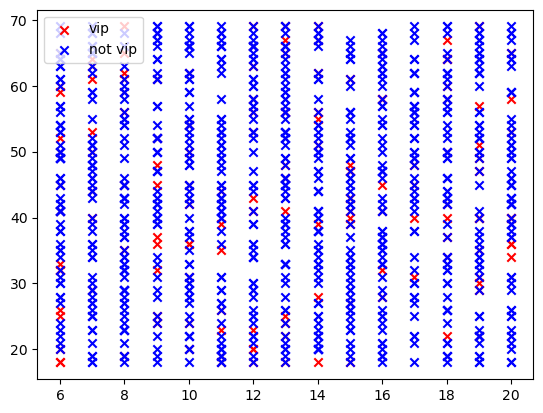

In [8]:
#نحاول نطلعهم بشكل مرئي عن طريق scatter

import matplotlib.pyplot as plt 

plt.scatter(dfvip['education'],dfvip['age'], color = 'red' , marker = 'x')
plt.scatter(dfnotvip['education'],dfnotvip['age'], color = 'blue' , marker = 'x')

plt.legend(['vip','not vip'])
plt.show()

## نقدر نبني الانحدار اللوجستي عن طريق الانحدار الخطي

In [9]:
#الان نبي نلقى مصنف يصنف العميل اذا مهم او لا vip or not vip 
#و ذلك حسب عمره و عدد سنوات التعلم 
# ممكن نلقى العلاقه الخطيه y = b0 + b1 * age + b2 * education
from sklearn.linear_model import LinearRegression 

model = LinearRegression()
model.fit(x,y)

b0 = round(model.intercept_ ,2)
b1 = round(model.coef_[0], 2)
b2 = round(model.coef_[1], 2)

print( ' the b0 is ' , b0 )
print( ' the b1 is ' , b1 )
print( 'the b2  ia ' , b2 )
# y = 0.17 + -0.0 * age + -0.0 * education 

 the b0 is  0.17
 the b1 is  -0.0
the b2  ia  -0.0


In [14]:
# عشان نحل المشكله نحتاج ان ننقل قيم y بين 0 و 1
# عشان نعتبر القيم الناتجه هي احد الصنفين  الاثنين وهو vip or not vip
#في البدايه  راح نحسب سيقمويند من ماث 

import math 
# هنا كتبنا معادله سيقمويند 
def sigmoid (y) :
    return 1 / (1 + pow (math.e, -y))
#هنا نعطي قيمه الي نبيها
age = 69
education = 12
# هتا تحدد الفاصل الي يفصل بين الصنفين
boundary = 0.5

# راح نحسب ال y باستخدام العلاقه الخطيه 
y_lr = b0 + b1 * age + b2 * education

#الان راح نحطه بالسيقمويند 
y_sig = sigmoid(y_lr)

#بعدين راح نقوله اذا كانت اكبر من العتبه  0.5 فيطلع شخص مهم 

if y_sig > boundary :
    print("vip")
else :
    print("not vip")
#لاحظ انه صنف الي عمره 69 و تعليمه 12 سنه انه مهم 
#استخدمنا عن طريف العلاقه الخطيه او الانحدار الخطي لبناء الانحدار اللوجستي

vip


## بناء الانحدار اللوجستي عن طريق مكتبته

In [15]:
#بدال ما تستخدم الانحدار الحطي متوفر لنا مكتبه 

from sklearn.linear_model import LogisticRegression

model = LogisticRegression()

model.fit(x.values, y)


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [18]:
age = 60
education = 12

example = [[age, education]]
#نخليه يتنبئ 
pred = model.predict(example)

if pred == 1 :
    print("vip")
else :
    print("not vip")

# يعني زيون الي بياناته عمره 60 و تعليمه 12 سنه غير مهم  صنفه 

not vip


In [20]:
# ممكن نطبه احتمالات الاصناف عن طريق predict_proba()
p_proba = model.predict_proba(example)
print(p_proba)
#اختمال يطون مهم 14 يالميه و 85 غير مهم 

[[0.85566004 0.14433996]]
